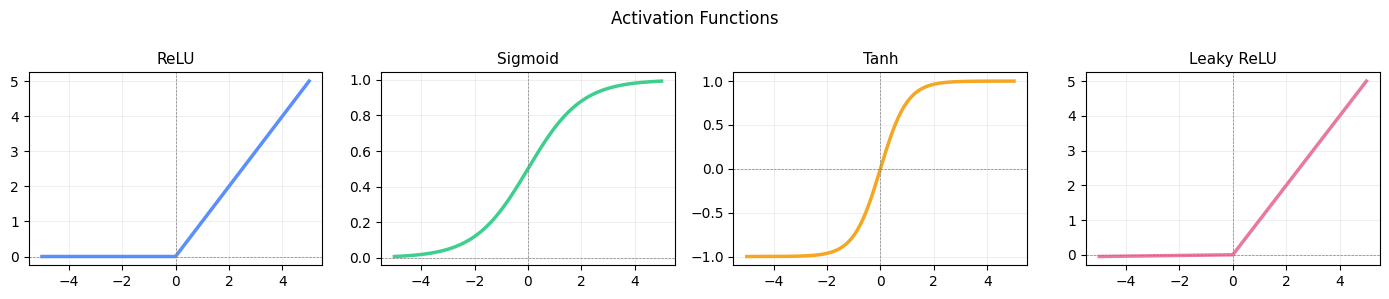

In [1]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-5, 5, 300)

relu = lambda x: np.maximum(0, x)
sigmoid = lambda x: 1 / (1 + np.exp(-x))
tanh_fn = np.tanh
leaky = lambda x: np.where(x > 0, x, 0.01 * x)





fig, axes = plt.subplots(1, 4, figsize=(14, 3))
fns = [relu, sigmoid, tanh_fn, leaky]
names = ['ReLU', 'Sigmoid', 'Tanh', 'Leaky ReLU']
cols = ['#5B8FF9','#3ECF8E','#F5A623','#E879A0']

for ax, fn, name, col in zip(axes, fns, names, cols):
  ax.plot(x, fn(x), color=col, linewidth=2.5)
  ax.axhline(0, color='gray', lw=0.5, ls='--')
  ax.axvline(0, color='gray', lw=0.5, ls='--')
  ax.set_title(name, fontsize=11)
  ax.grid(alpha=0.2)
plt.suptitle('Activation Functions', fontsize=12)
plt.tight_layout(); plt.show()

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
print(f'Train: {X_train.shape} Test: {X_test.shape}')



model = keras.Sequential([
keras.Input(shape=(784,)),

layers.Dense(234, activation='relu'),
layers.Dropout(0.2),

layers.Dense(64, activation='relu'),
layers.Dropout(0.2),

layers.Dense(10, activation='softmax'),
])
model.summary()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (60000, 784) Test: (10000, 784)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 234)            │       183,690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 234)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        15,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,380 (778.83 KB)

 Trainable params: 199,380 (778.83 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)


from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


early_stop = EarlyStopping(monitor='val_loss', patience=5,
restore_best_weights=True, verbose=1)


reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
patience=3, min_lr=1e-6, verbose=1)



history = model.fit(
X_train, y_train,
epochs=50,
batch_size=128,
validation_split=0.1,
callbacks=[early_stop, reduce_lr],
verbose=1
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8785 - loss: 0.4045 - val_accuracy: 0.9633 - val_loss: 0.1271 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9486 - loss: 0.1731 - val_accuracy: 0.9720 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9626 - loss: 0.1240 - val_accuracy: 0.9753 - val_loss: 0.0819 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9701 - loss: 0.1000 - val_accuracy: 0.9768 - val_loss: 0.0758 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9745 - loss: 0.0836 - val_accuracy: 0.9797 - val_loss: 0.0734 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9782 - loss: 0.0720 - val_accuracy: 0.9785 - val_loss: 0.0783 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9802 - loss: 0.0619 

Test Accuracy: 98.11%
Test Loss: 0.0677


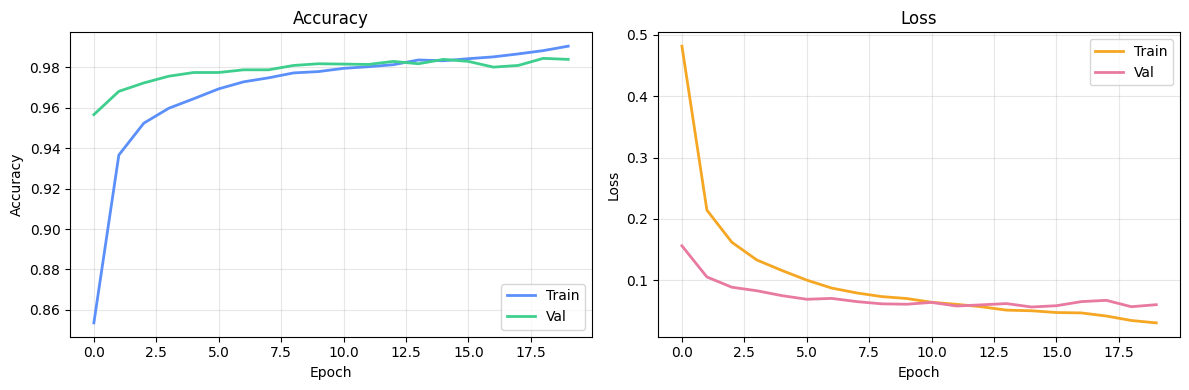

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train', color='#5B8FF9', lw=2)
ax1.plot(history.history['val_accuracy'], label='Val', color='#3ECF8E', lw=2)
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'], label='Train', color='#F5A623', lw=2)
ax2.plot(history.history['val_loss'], label='Val', color='#E879A0', lw=2)
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

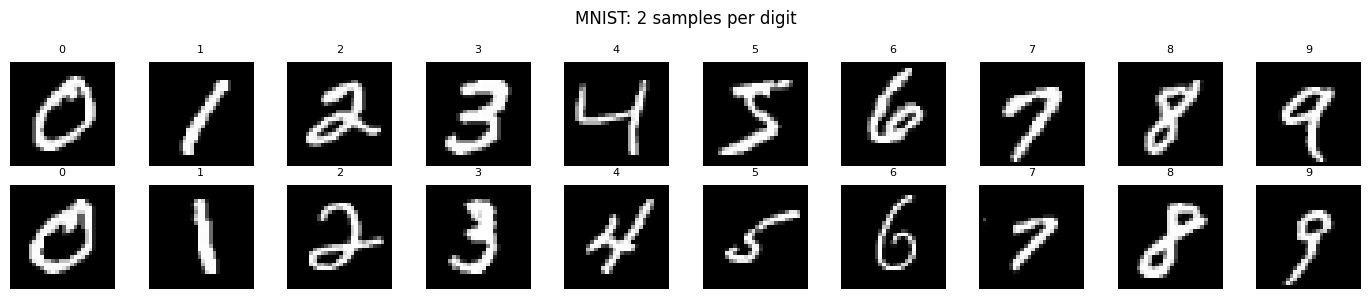

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for d in range(10):
  for r, offset in enumerate([0, 1]):
    idx = np.where(y_train == d)[0][offset]
    axes[r, d].imshow(X_train[idx].reshape(28,28), cmap='gray')
    axes[r, d].set_title(str(d), fontsize=8); axes[r, d].axis('off')
plt.suptitle('MNIST: 2 samples per digit'); plt.tight_layout(); plt.show()
def make_model(h1=256, h2=128, drop=0.3):
  m = keras.Sequential([
  keras.Input(shape=(784,)),
  layers.Dense(h1, activation='relu'),
  layers.Dropout(drop),
  layers.Dense(h2, activation='relu'),
                       layers.Dropout(drop),
  layers.Dense(10, activation='softmax'),
  ])
  m.compile(optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])
  return m
model = make_model()
model.summary()

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8734 - loss: 0.4148 - val_accuracy: 0.9640 - val_loss: 0.1285
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9473 - loss: 0.1773 - val_accuracy: 0.9708 - val_loss: 0.0937
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9611 - loss: 0.1325 - val_accuracy: 0.9738 - val_loss: 0.0888
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9674 - loss: 0.1065 - val_accuracy: 0.9798 - val_loss: 0.0715
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9718 - loss: 0.0919 - val_accuracy: 0.9813 - val_loss: 0.0653
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9760 - loss: 0.0788 - val_accuracy: 0.9797 - val_loss: 0.0698
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9787 - loss: 0.0692 - val_accuracy: 0.9805 - val_loss: 0.0649
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9801 - loss: 0.0619 - val_acc

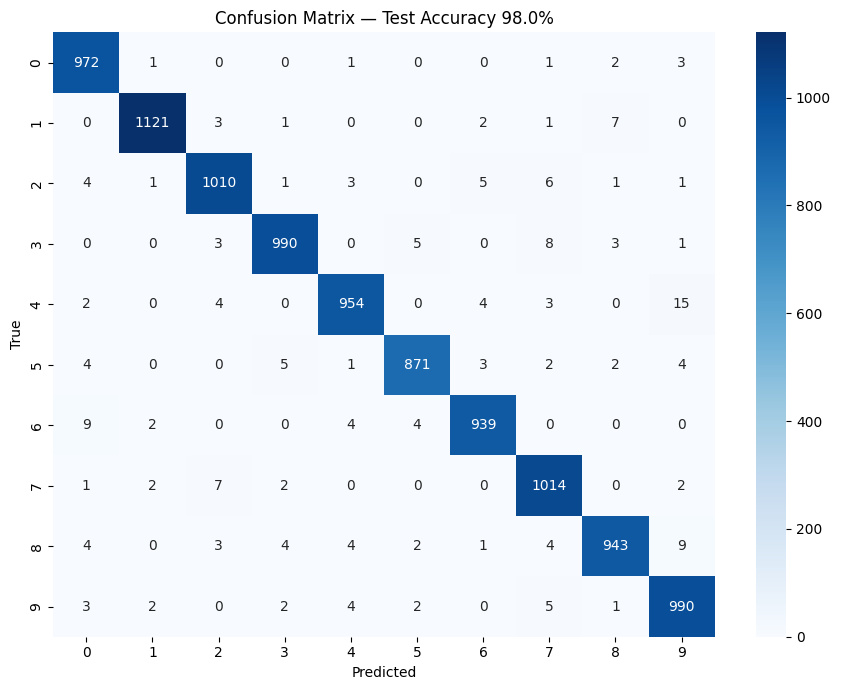

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.99      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.99      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

Misclassified: 196 out of 10000


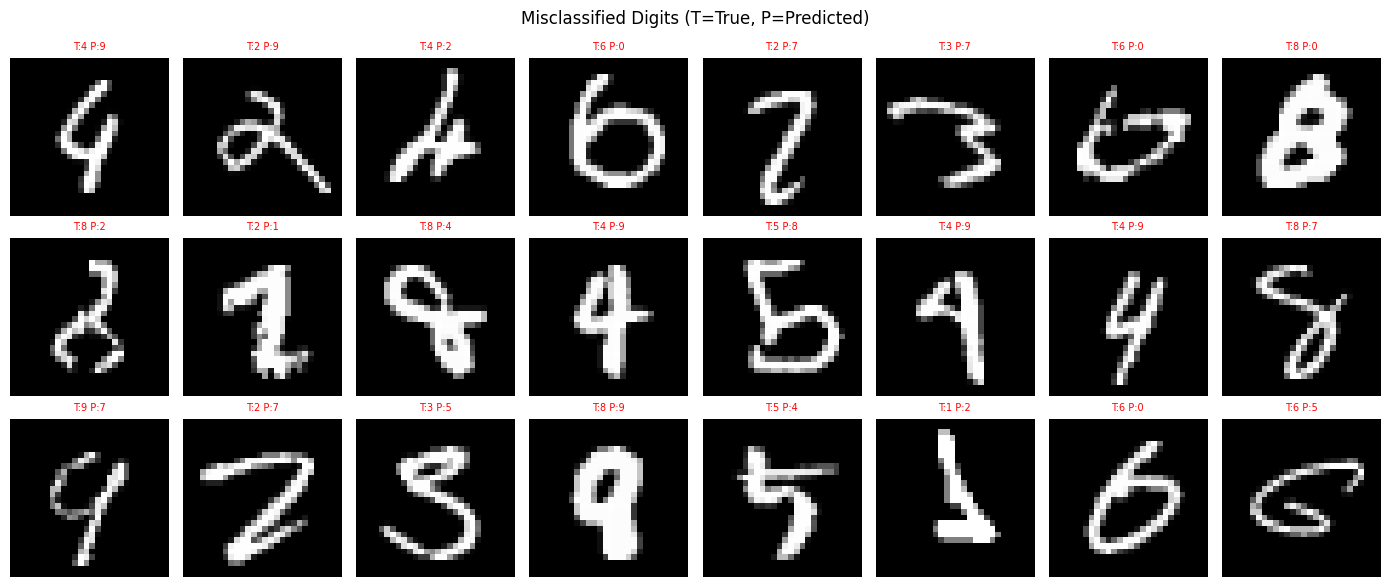

In [ ]:
history = model.fit(
X_train, y_train, epochs=30, batch_size=128,
validation_split=0.1,
callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
verbose=1)
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {acc*100:.2f}%')
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix — Test Accuracy {acc*100:.1f}%')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred))
wrong = np.where(y_pred != y_test)[0]
print(f'Misclassified: {len(wrong)} out of {len(y_test)}')
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
  if i < len(wrong):
    idx = wrong[i]
    ax.imshow(X_test[idx].reshape(28,28), cmap='gray')
    ax.set_title(f'T:{y_test[idx]} P:{y_pred[idx]}',
    color='red', fontsize=7)
  ax.axis('off')
plt.suptitle('Misclassified Digits (T=True, P=Predicted)')
plt.tight_layout(); plt.show()
configs = [
(64, 32, 0.0, 'Small / no dropout'),
(128, 64, 0.2, 'Medium / light dropout'),
(256, 128, 0.3, 'Large / moderate dropout'),
]
for h1, h2, dr, label in configs:
  m = make_model(h1, h2, dr)
  m.fit(X_train, y_train, epochs=15, batch_size=128,
    validation_split=0.1, verbose=0,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])
_, a = m.evaluate(X_test, y_test, verbose=0)
print(f'{label:35s} Accuracy: {a*100:.2f}%')

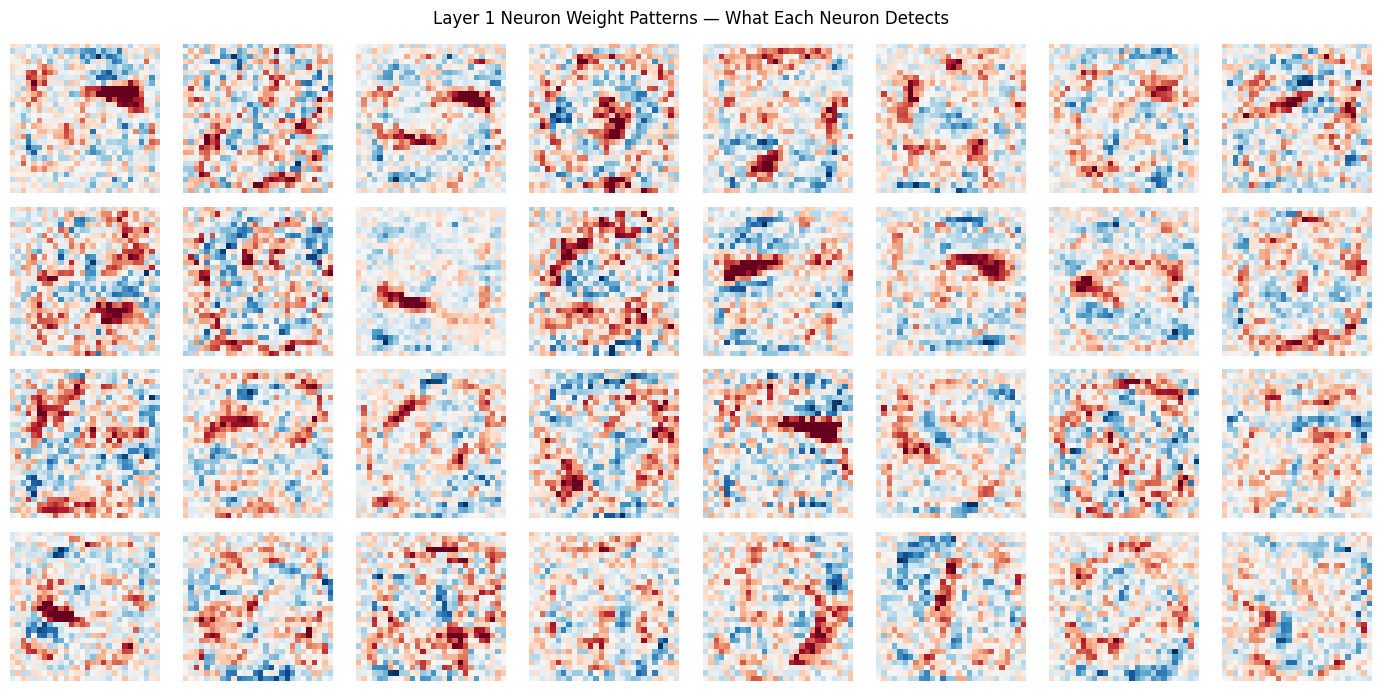

In [ ]:
weights = model.layers[0].get_weights()[0]
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
  w = weights[:, i].reshape(28, 28)
  ax.imshow(w, cmap='RdBu', vmin=-w.max(), vmax=w.max())
  ax.axis('off')
plt.suptitle('Layer 1 Neuron Weight Patterns — What Each Neuron Detects')
plt.tight_layout(); plt.show()